╔═══════════════════════════════════════╗
║  SMART GLOVE - ANALYSE DU DATASET     ║
╚═══════════════════════════════════════╝

📂 9 fichier(s) trouvé(s)

   ✅ dataset_A_20260102_094635.csv: 204 lignes
   ✅ dataset_B_20260102_095227.csv: 206 lignes
   ✅ dataset_C_20260102_095749.csv: 205 lignes
   ✅ dataset_D_20260102_100109.csv: 204 lignes
   ✅ dataset_E_20260102_100411.csv: 205 lignes
   ✅ dataset_L_20260102_100651.csv: 205 lignes
   ✅ dataset_MERCI_20260102_100941.csv: 206 lignes
   ✅ dataset_OK_20260102_101704.csv: 203 lignes
   ✅ dataset_STOP_20260102_094311.csv: 202 lignes

✅ Dataset total: 1840 échantillons

📊 INFORMATIONS GÉNÉRALES
Nombre total d'échantillons: 1840
Nombre de colonnes: 12
Colonnes: timestamp, flex_thumb, flex_index, flex_middle, gyro_x, gyro_y, gyro_z, accel_x, accel_y, accel_z, label, datetime

🎯 DISTRIBUTION DES GESTES

| Geste     | Nombre d'échantillons | Pourcentage |
|-----------|----------------------|-------------|
| A         | 204                  |  11.

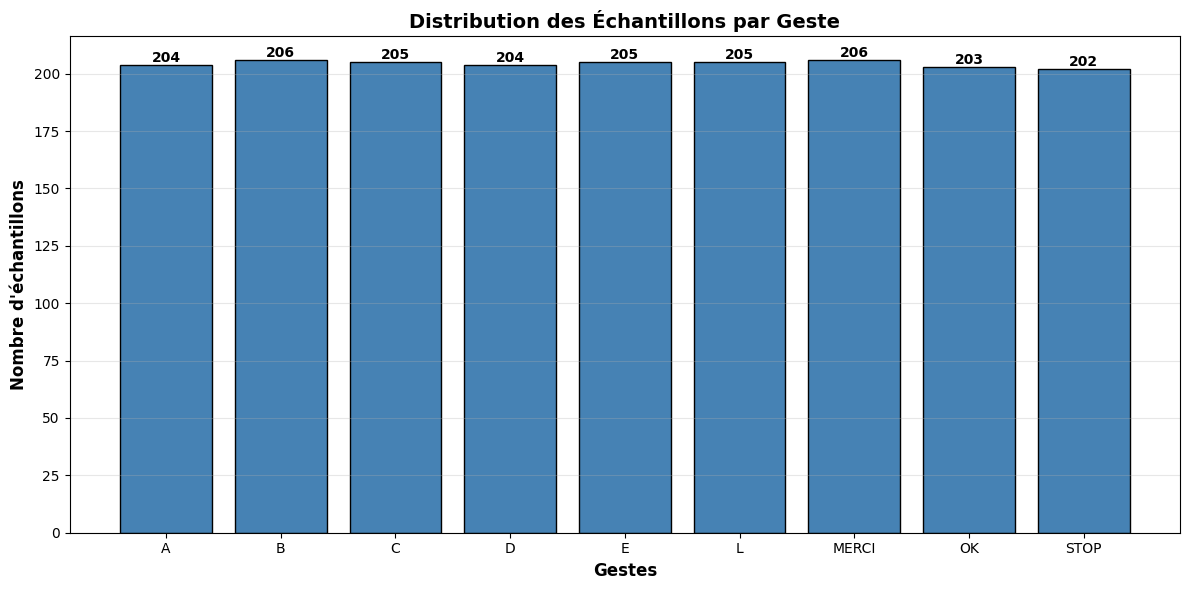

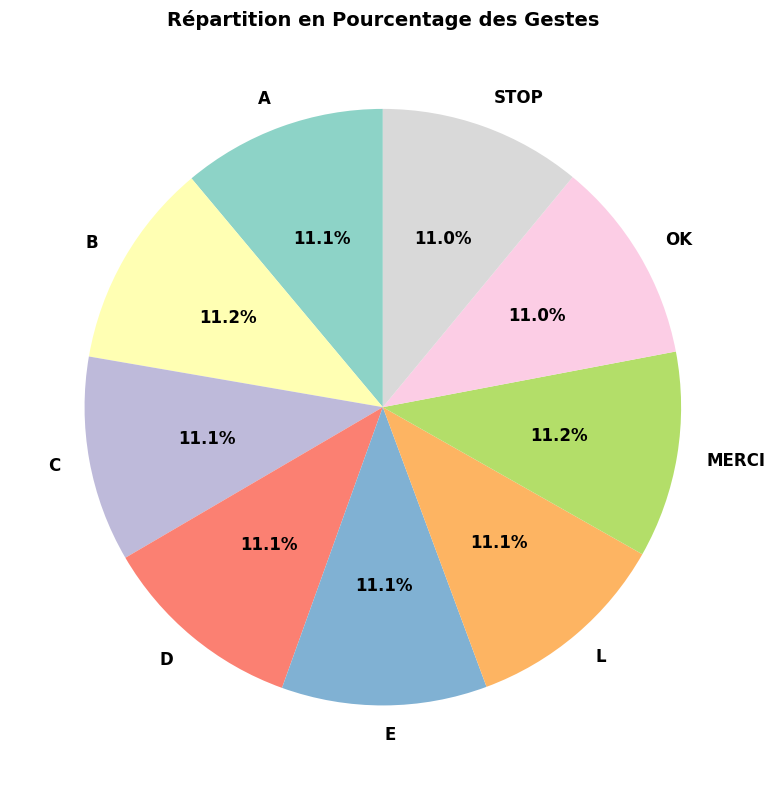

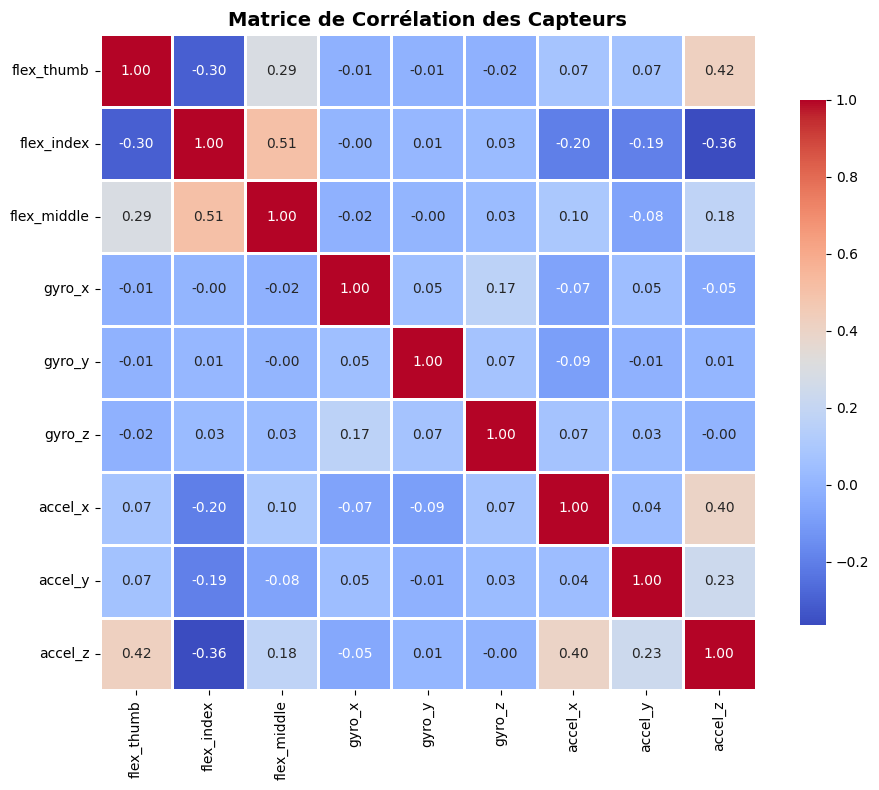

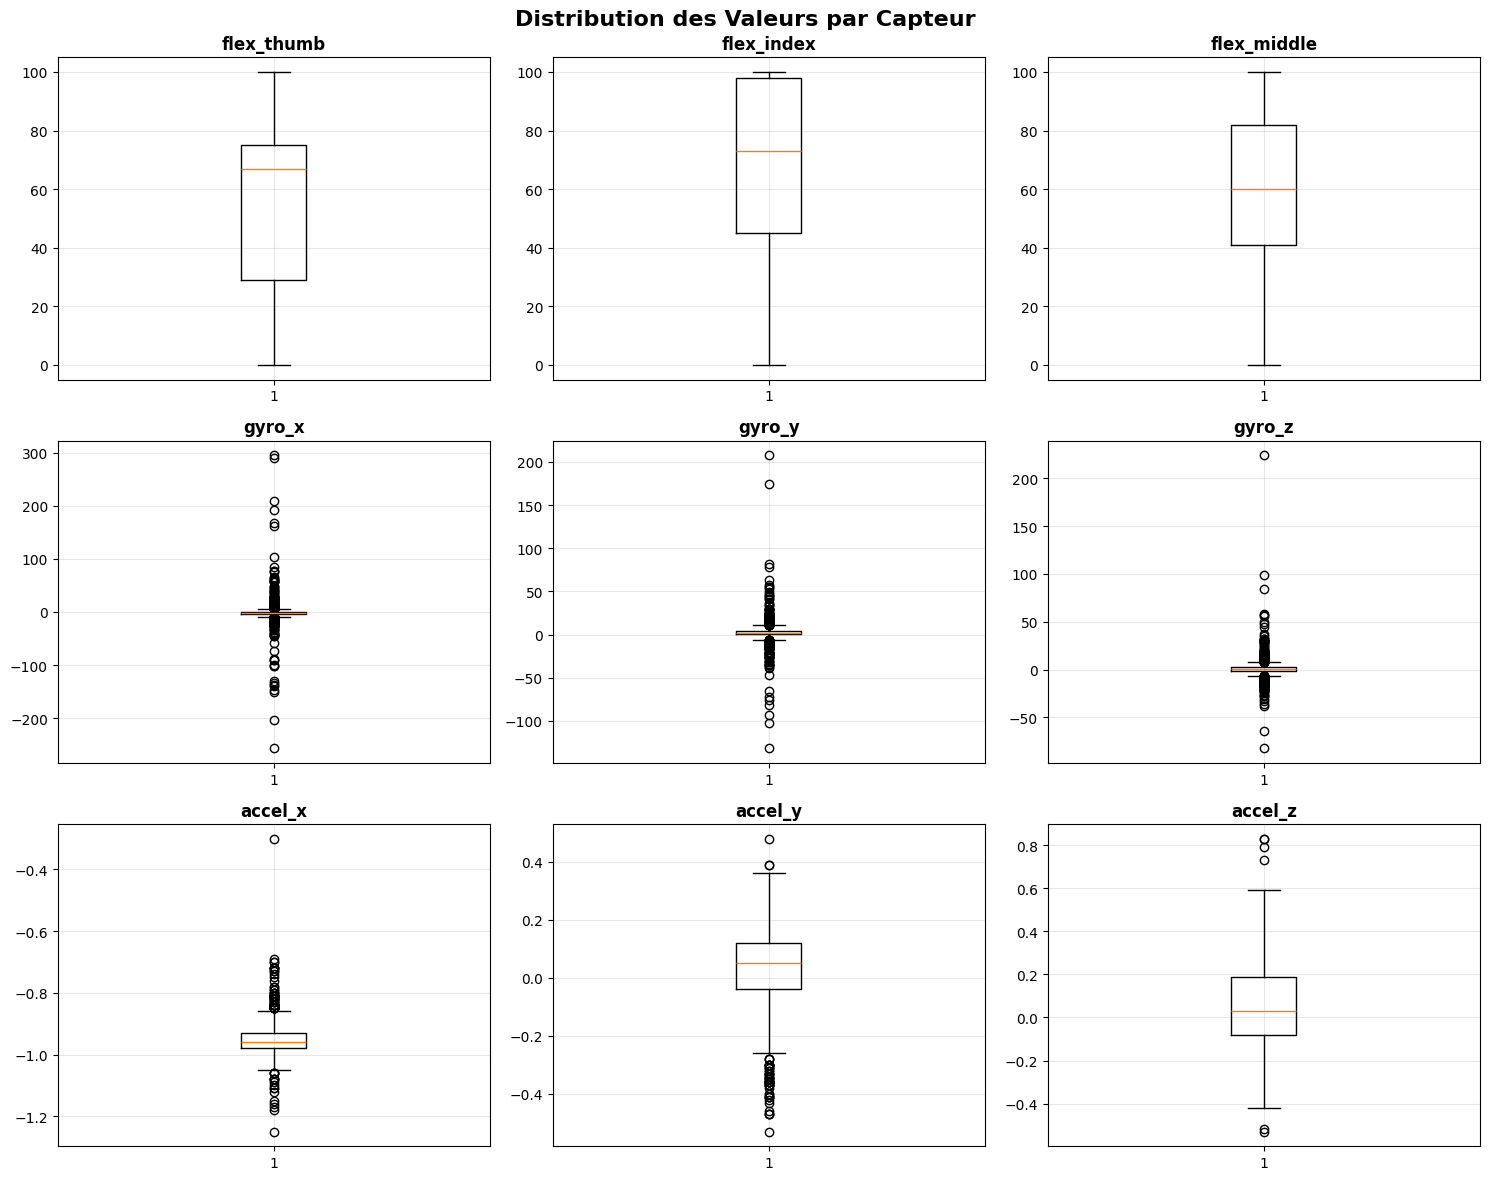

In [2]:
"""
SMART GLOVE - Analyse du Dataset
Fichier: analyze_dataset.py

Installation:
pip install pandas matplotlib seaborn

Utilisation:
python analyze_dataset.py
"""

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("╔═══════════════════════════════════════╗")
print("║  SMART GLOVE - ANALYSE DU DATASET     ║")
print("╚═══════════════════════════════════════╝\n")

# ========== CHARGER TOUS LES CSV ==========
DATASET_FOLDER = "datasets"
csv_files = glob.glob(os.path.join(DATASET_FOLDER, "*.csv"))

if not csv_files:
    print("❌ Aucun fichier CSV trouvé dans", DATASET_FOLDER)
    exit(1)

print(f"📂 {len(csv_files)} fichier(s) trouvé(s)\n")

# Fusionner tous les CSV
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)
    print(f"   ✅ {os.path.basename(file)}: {len(df)} lignes")

data = pd.concat(dataframes, ignore_index=True)
print(f"\n✅ Dataset total: {len(data)} échantillons\n")

# ========== ANALYSE DE BASE ==========
print("="*70)
print("📊 INFORMATIONS GÉNÉRALES")
print("="*70)
print(f"Nombre total d'échantillons: {len(data)}")
print(f"Nombre de colonnes: {len(data.columns)}")
print(f"Colonnes: {', '.join(data.columns)}\n")

# ========== DISTRIBUTION DES GESTES ==========
print("="*70)
print("🎯 DISTRIBUTION DES GESTES")
print("="*70 + "\n")

geste_counts = data['label'].value_counts().sort_index()
total = len(data)

print("| Geste     | Nombre d'échantillons | Pourcentage |")
print("|-----------|----------------------|-------------|")
for geste, count in geste_counts.items():
    pct = (count / total * 100)
    print(f"| {geste:<9} | {count:<20} | {pct:>6.2f}%    |")
print(f"| **TOTAL** | **{total:<18}** | **100.00%** |")

# ========== STATISTIQUES D'ÉQUILIBRE ==========
print("\n" + "="*70)
print("⚖️ ANALYSE DE L'ÉQUILIBRE")
print("="*70)

min_count = geste_counts.min()
max_count = geste_counts.max()
variation = ((max_count - min_count) / min_count * 100)

print(f"\nGeste le moins représenté: {geste_counts.idxmin()} ({min_count} échantillons)")
print(f"Geste le plus représenté: {geste_counts.idxmax()} ({max_count} échantillons)")
print(f"Variation: {variation:.1f}%\n")

if variation < 20:
    print("✅ Dataset ÉQUILIBRÉ (variation < 20%)")
    print("   → Pas besoin de techniques de rééquilibrage")
elif variation < 50:
    print("⚠️ Dataset LÉGÈREMENT DÉSÉQUILIBRÉ (20% < variation < 50%)")
    print("   → Envisager class_weight='balanced'")
else:
    print("❌ Dataset DÉSÉQUILIBRÉ (variation > 50%)")
    print("   → Utiliser SMOTE ou sous-échantillonnage")

# ========== STATISTIQUES DES CAPTEURS ==========
print("\n" + "="*70)
print("📈 STATISTIQUES DES CAPTEURS")
print("="*70 + "\n")

feature_columns = [
    'flex_thumb', 'flex_index', 'flex_middle',
    'gyro_x', 'gyro_y', 'gyro_z',
    'accel_x', 'accel_y', 'accel_z'
]

stats = data[feature_columns].describe()
print(stats.round(2))

# ========== VALEURS MANQUANTES ==========
print("\n" + "="*70)
print("⚠️ VALEURS MANQUANTES")
print("="*70 + "\n")

missing = data.isnull().sum()
if missing.sum() == 0:
    print("✅ Aucune valeur manquante détectée!")
else:
    print(missing[missing > 0])

# ========== VISUALISATIONS ==========
print("\n" + "="*70)
print("📊 GÉNÉRATION DES GRAPHIQUES")
print("="*70 + "\n")

# 1. Graphique en barres - Distribution des gestes
plt.figure(figsize=(12, 6))
bars = plt.bar(geste_counts.index, geste_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Gestes', fontsize=12, fontweight='bold')
plt.ylabel('Nombre d\'échantillons', fontsize=12, fontweight='bold')
plt.title('Distribution des Échantillons par Geste', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_gestes.png', dpi=300)
print("✅ Sauvegardé: distribution_gestes.png")

# 2. Graphique circulaire
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(geste_counts)))
plt.pie(geste_counts.values, labels=geste_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Répartition en Pourcentage des Gestes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('repartition_gestes.png', dpi=300)
print("✅ Sauvegardé: repartition_gestes.png")

# 3. Heatmap de corrélation des capteurs
plt.figure(figsize=(10, 8))
correlation = data[feature_columns].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation des Capteurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_capteurs.png', dpi=300)
print("✅ Sauvegardé: correlation_capteurs.png")

# 4. Boxplot pour détecter les outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution des Valeurs par Capteur', fontsize=16, fontweight='bold')

for idx, col in enumerate(feature_columns):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(data[col].dropna())
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_capteurs.png', dpi=300)
print("✅ Sauvegardé: boxplot_capteurs.png")

# ========== RÉSUMÉ FINAL ==========
print("\n" + "="*70)
print("✅ ANALYSE TERMINÉE!")
print("="*70)
print("\nFichiers générés:")
print("   • distribution_gestes.png")
print("   • repartition_gestes.png")
print("   • correlation_capteurs.png")
print("   • boxplot_capteurs.png")
print("\n💡 Vous pouvez maintenant utiliser ces données dans votre rapport!")